In [41]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

########################################################   CONSTANTS   ########################################################
SunPower = 1361                                     # Raw power of sunlight when it reaches the satellite in W/m2
BOLSolarCellEfficiency = 0.3                        # Beginning Of Life efficiency of the Solar Cells
EOLSolarCellEfficiency = 0.209                      # End Of Life efficiency of the Solar Cells
BatteryDegradationFittingConstant = 0.0000348       # Curve fitting constant in s^-1/2

####################################################   ITERATING CONSTANTS   ##################################################
# Each value is defined as: value = [minimum, maximum, number_of_points]
PanelSurface = [1, 10, 21]                            # Effective surface of the Solar Panels (just the surface of the cells)
BOLBatteryCapacity = [400, 2000, 21]                 # Initial capacity of the battery in Wh
PowerDraw = [200, 2000, 21]                          # Power drawn by the system 

#######################################################   MAIN PROGRAM   ######################################################
# Import data from csv files
SolarIntensity = pd.read_csv('Solar_intensity.csv')['Intensity']
SunVector = pd.read_csv('sun_vector.csv')[['x (km)', 'y (km)', 'z (km)']]

# Check if the files match dates and times
Times = pd.read_csv('Solar_intensity.csv')[['Time (UTCG)']]
Times = Times.rename(columns={'Time (UTCG)': 'Solar Intensity'})
Times['Sun Vector'] = pd.read_csv('sun_vector.csv')['Time (UTCG)']
Times['Solar Intensity'] = pd.to_datetime(Times['Solar Intensity'])
Times['Sun Vector'] = pd.to_datetime(Times['Sun Vector'])
if (Times['Sun Vector'] != Times['Solar Intensity']).any():
    if len(Times['Sun Vector']) != len(Times['Solar Intensity']):
        raise ValueError('>>> ERROR: Files have different number of rows. Files may be from different simulations')
    else:
        raise ValueError('>>> ERROR: Timestamps are not the same between files. Files may be from different simulations')
    
# Create timesteps for calculations
Times['Timestep (s)'] = Times['Solar Intensity'].diff().dt.total_seconds().fillna(0)
Times['Timestep (h)'] = Times['Timestep (s)']/3600
Times['CumulativeTime'] = Times['Timestep (s)'].cumsum()

# Calculate the sines of the angles of incidence of the sun from each plane
SunVector['Sine of X Face Angle'] = SunVector['x (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))
SunVector['Sine of Y Face Angle'] = SunVector['y (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))
SunVector['Sine of Z Face Angle'] = SunVector['z (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))

# Calculate efficiency of the Solar Cells for the duration of the mission
PanelEfficiency = pd.Series(np.linspace(BOLSolarCellEfficiency, EOLSolarCellEfficiency, num=len(Times['Sun Vector'])))

# Calculate generation for every panel size
Generation = {}
for IterationPanelSurface in np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]):
    # Calculate the power generation from each satellite face
    Generation[f'{IterationPanelSurface}m^2'] = pd.DataFrame()
    Generation[f'{IterationPanelSurface}m^2']['W generated in face X'] = SunPower * SunVector['Sine of X Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Y'] = SunPower * SunVector['Sine of Y Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Z'] = SunPower * SunVector['Sine of Z Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)

# Calculate battery degradation for every battery size
RealBatteryCapacity = pd.DataFrame()
BatteryDegradationFactor = (1 - (BatteryDegradationFittingConstant * np.sqrt(Times['CumulativeTime'])))
for IterationBOLBatteryCapacity in np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2]):
    # Calculate the degradation of the battery in each point in time
    RealBatteryCapacity[f'{IterationBOLBatteryCapacity}Wh'] = IterationBOLBatteryCapacity * BatteryDegradationFactor

# Create a key for every panel position
PanelPositions = [['W generated in face X', 'Panels in face X'],
                  ['W generated in face Y', 'Panels in face Y'],
                  ['W generated in face Z', 'Panels in face Z']]

# Initialize a list of every configuration that goes out of battery at any point
OutOfBattery = []

# Run through every combination of values to calculate state of charge at every point of the orbit in every configuration
Charge = {}
for IterationPanelSurface in tqdm(np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]), desc='Loading'):
    Charge[f'{IterationPanelSurface}m^2'] = {}
    for IterationBOLBatteryCapacity in tqdm(np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2]), desc='Battery sizes', leave=False):
        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'] = {}
        for IterationPowerDraw in tqdm(np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2]), desc='Power configs', leave=False):
            Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'] = pd.DataFrame()
            for PanelPositionIndex in range(3):
                # Define route to the df being built and fill it
                dfActual = Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W']
                dfActual[PanelPositions[PanelPositionIndex][1]] = np.nan

                # Redefine df as np arrays for faster calculations
                GenerationArray = Generation[f'{IterationPanelSurface}m^2'][PanelPositions[PanelPositionIndex][0]].to_numpy()
                MaximumBatteryArray = RealBatteryCapacity[f'{IterationBOLBatteryCapacity}Wh'].to_numpy()

                # Calculate energy gained or lost
                NetEnergy = (GenerationArray - IterationPowerDraw) * Times['Timestep (h)']

                # Throwaway list for value storage pre-dump
                ChargeList = [IterationBOLBatteryCapacity]

                # Reinitialize flag for going out of battery
                BatteryDown = 0
                for i in range(len(Times['Sun Vector'])-1):
                    # Calculate state of charge
                    NextValue = ChargeList[-1] + NetEnergy[i+1]

                    # Check if energy storage is within its maximum and minimum values
                    if NextValue > MaximumBatteryArray[i+1]:
                        ChargeList.append(MaximumBatteryArray[i+1])
                    elif NextValue < 0:
                        ChargeList.append(0)
                        # Add configuration to the list of going out of battery
                        if BatteryDown == 0:
                            OutOfBattery.append([f'{IterationPanelSurface}m^2', f'{IterationBOLBatteryCapacity}Wh', f'{IterationPowerDraw}W', PanelPositions[PanelPositionIndex][1]])
                            BatteryDown = 1
                    else:
                        ChargeList.append(NextValue)
                    
                # Dump the throwaway list into the df
                dfActual[PanelPositions[PanelPositionIndex][1]] = ChargeList
print('guatafak')

C:\Users\escri\AppData\Local\Temp\ipykernel_19884\2326119306.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Times['Solar Intensity'] = pd.to_datetime(Times['Solar Intensity'])
C:\Users\escri\AppData\Local\Temp\ipykernel_19884\2326119306.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Times['Sun Vector'] = pd.to_datetime(Times['Sun Vector'])


Loading:   0%|          | 0/21 [00:00<?, ?it/s]

Battery sizes:   0%|          | 0/21 [00:00<?, ?it/s]

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

...

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

Power configs:   0%|          | 0/21 [00:00<?, ?it/s]

guatafak


In [42]:
print(OutOfBattery)

[['1.0m^2', '400.0Wh', '200.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '200.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '290.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '290.0W', 'Panels in face Y'], ['1.0m^2', '400.0Wh', '290.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '380.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '380.0W', 'Panels in face Y'], ['1.0m^2', '400.0Wh', '380.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '470.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '470.0W', 'Panels in face Y'], ['1.0m^2', '400.0Wh', '470.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '560.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '560.0W', 'Panels in face Y'], ['1.0m^2', '400.0Wh', '560.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '650.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '650.0W', 'Panels in face Y'], ['1.0m^2', '400.0Wh', '650.0W', 'Panels in face Z'], ['1.0m^2', '400.0Wh', '740.0W', 'Panels in face X'], ['1.0m^2', '400.0Wh', '740.0W', 'Panels in fa

KeyError: '3.0m^2'

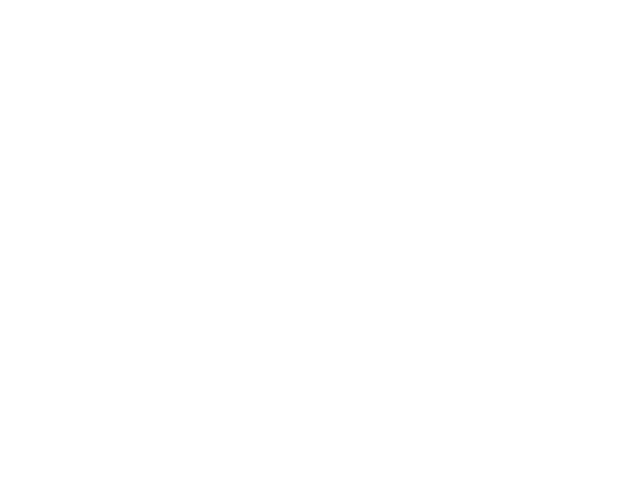

In [43]:
plt.figure("Charge respect time")
plt.title("Charge respect time")
plt.clf()
plt.plot(Charge['3.0m^2']['600.0Wh']['1000.0W']['Panels in face Y'], color = 'blue')
plt.plot(Charge['5.0m^2']['600.0Wh']['1000.0W']['Panels in face Y'], color = 'red')
plt.show()
'''list = []
for i in range(len(Charge['5.0m^2']['600.0Wh']['600.0W']['Panels in face Y'])):
    if (Charge['5.0m^2']['600.0Wh']['600.0W']['Panels in face Y'][i] != Charge['3.0m^2']['600.0Wh']['600.0W']['Panels in face Y'][i]):
        list.append(i)
print(list)
print(Charge['5.0m^2']['600.0Wh']['600.0W']['Panels in face Y'][364])
print(Charge['3.0m^2']['600.0Wh']['600.0W']['Panels in face Y'][364])'''

C:\Users\escri\AppData\Local\Temp\ipykernel_19884\1734872090.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(X, Y, Z, cmap = cm.turbo, linewidth=0, antialiased=False)


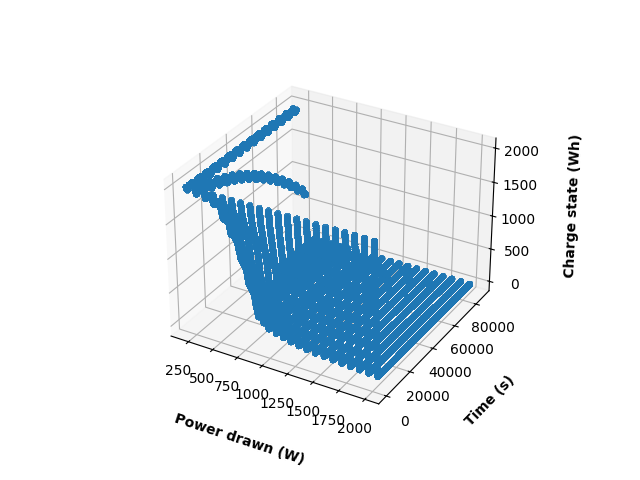

In [ ]:
from matplotlib import cm
plt.close()
plt.figure("Charge graph for every power draw")
plt.title("Charge graph for every power draw")
plt.clf()
ax = plt.axes(projection='3d')
ax.set_xlabel('Power drawn (W)', labelpad = 15, fontweight = 'bold')
ax.set_ylabel('Time (s)', labelpad = 15, fontweight = 'bold')
ax.set_zlabel('Charge state (Wh)', labelpad = 15, fontweight = 'bold')

xdata = []
ydata = []

Z = []
for Xvalue in np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2]):
    xdata.append(Xvalue)
    temp = []
    for j in range(len(Times['CumulativeTime'])):
        temp.append(Charge['1.0m^2']['2000.0Wh'][f'{Xvalue}W']['Panels in face Y'].iloc[j])
    Z.append(temp)
Z = np.array(Z)
Z = Z.T

ydata = Times['CumulativeTime']

X, Y = np.meshgrid(xdata, ydata)

ax.scatter3D(X, Y, Z, cmap = cm.turbo, linewidth=0, antialiased=False)
plt.show()

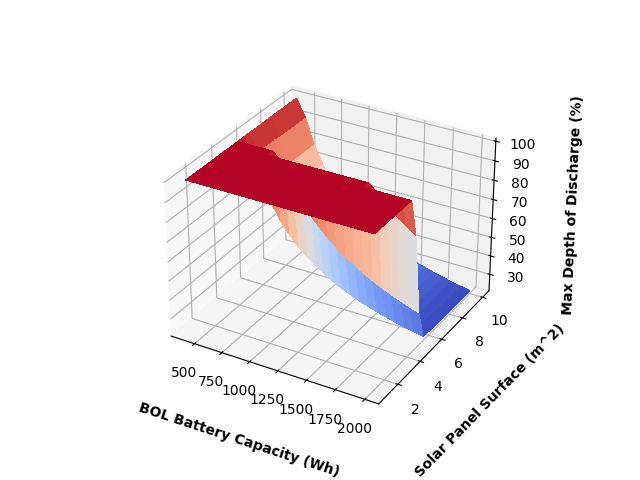

In [46]:
plt.close()
plt.figure("Minimum charge for every panel size and battery size")
plt.clf()
ax = plt.axes(projection='3d')
ax.set_xlabel('BOL Battery Capacity (Wh)', labelpad = 15, fontweight = 'bold')
ax.set_ylabel('Solar Panel Surface (m^2)', labelpad = 15, fontweight = 'bold')
ax.set_zlabel('Max Depth of Discharge (%)', labelpad = 15, fontweight = 'bold')

xdata = []
ydata = []
Z = []

for Yvalue in np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]):
    ydata.append(Yvalue)

for Xvalue in np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2]):
    xdata.append(Xvalue)
    tempZ = []
    for Yvalue in np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]):
        tempZ.append(100-((min(Charge[f'{Yvalue}m^2'][f'{Xvalue}Wh']['1100.0W']['Panels in face Y']))*100/Xvalue))
    Z.append(tempZ)
Z = np.array(Z)
Z = Z.T

X, Y = np.meshgrid(xdata, ydata)

ax.plot_surface(X, Y, Z, cmap = cm.coolwarm, linewidth=0, antialiased=False)
plt.show()